<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/Anticipative_CASIA_B_HRNet_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

✅ All libraries imported successfully
PyTorch version: 2.10.0+cu128
Device: cuda


In [2]:
# CELL 0 — Download CASIA-B SimCC via kagglehub
!pip install kagglehub --quiet

import kagglehub

path = kagglehub.dataset_download("mireillejabbour/casia-b-hrnet")
print("✅ Path to dataset files:", path)

100%|██████████| 223M/223M [00:11<00:00, 20.7MB/s]

Extracting files...


✅ Path to dataset files: /root/.cache/kagglehub/datasets/mireillejabbour/casia-b-hrnet/versions/1


In [ ]:
# CELL 2 — Inspect the downloaded dataset structure
# Run this and paste the output here so I can adapt the loader

from pathlib import Path
from collections import Counter

DATA_ROOT = Path(path)   # 'path' comes from CELL 0
print(f"Dataset root: {DATA_ROOT}\n")

# --- Show folder structure (first 4 levels) ---
print("=== FOLDER STRUCTURE ===")
for root, dirs, files_ in os.walk(DATA_ROOT):
    level = str(root).replace(str(DATA_ROOT), '').count(os.sep)
    if level > 4:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files_)[:5]:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{indent}  📄 {f}  ({size:.1f} KB)")

# --- Count file types ---
all_files = [f for f in DATA_ROOT.rglob('*') if f.is_file()]
exts = Counter(f.suffix.lower() for f in all_files)
print(f"\n=== FILE TYPES ===")
print(f"Total files : {len(all_files)}")
for ext, count in exts.most_common():
    print(f"  {ext if ext else 'no_ext'} : {count} files")

# --- Peek inside first 2 files ---
print("\n=== PEEK INSIDE FIRST 2 FILES ===")
for fp in all_files[:2]:
    ext = fp.suffix.lower()
    size = fp.stat().st_size / 1024
    print(f"\n📄 {fp.name}  ({size:.1f} KB)")
    print(f"   Full path: {fp}")
    try:
        if ext == '.pkl':
            with open(fp, 'rb') as f:
                d = pickle.load(f)
            if isinstance(d, np.ndarray):
                print(f"   → ndarray  shape={d.shape}  dtype={d.dtype}")
                print(f"   → min={d.min():.3f}  max={d.max():.3f}")
            elif isinstance(d, dict):
                print(f"   → dict  keys={list(d.keys())[:8]}")
                for k in list(d.keys())[:2]:
                    v = d[k]
                    print(f"      '{k}': type={type(v).__name__}  "
                          f"shape={np.array(v).shape if hasattr(v,'__len__') else v}")
            elif isinstance(d, list):
                print(f"   → list  len={len(d)}  "
                      f"elem_type={type(d[0]).__name__}")
                if hasattr(d[0], 'shape'):
                    print(f"   → elem_shape={d[0].shape}")
                elif hasattr(d[0], '__len__'):
                    print(f"   → elem_shape={np.array(d[0]).shape}")

        elif ext == '.npy':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npy  shape={d.shape}  dtype={d.dtype}")

        elif ext == '.npz':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npz  keys={list(d.keys())}")
            for k in list(d.keys())[:3]:
                print(f"      '{k}': shape={d[k].shape}")

        elif ext == '.csv':
            df = pd.read_csv(fp, nrows=3)
            print(f"   → csv  shape={df.shape}")
            print(f"   → cols={list(df.columns[:8])}")
            print(df.head(2).to_string())

    except Exception as e:
        print(f"   ❌ Error: {e}")

In [3]:
# CELL 2 — Load CASIA-B HRNet
# Structure : {subject}/{condition}-{seq}/{view}/{view}.pkl
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import Counter

DATA_ROOT = Path(path) / "CASIA-B_HRNet"

COCO_KEYPOINTS = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

SKELETON_PAIRS = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def load_casia_b(root_path, conditions=None, views=None, max_subjects=None):
    """
    Charge les séquences CASIA-B HRNet.
    Structure dossiers : {subject}/{condition}-{seq}/{view}/{view}.pkl
    ex : 001/bg-01/000/000.pkl

    Arguments:
        conditions  : liste ex. ['nm','bg','cl'] ou None = toutes
        views       : liste ex. ['000','090','180'] ou None = toutes
        max_subjects: int ou None

    Retourne:
        sequences : liste de np.array (T, 17, 3)
        metadata  : liste de dicts {subject, condition, sequence, view, path, frames}
    """
    root = Path(root_path)
    pkl_files = sorted(root.rglob("*.pkl"))

    if len(pkl_files) == 0:
        raise FileNotFoundError(f"Aucun fichier .pkl trouvé dans {root}")

    sequences = []
    metadata  = []
    skipped   = 0

    for fp in tqdm(pkl_files, desc="Loading CASIA-B HRNet"):
        # Chemin relatif : 001/bg-01/000/000.pkl
        parts = fp.relative_to(root).parts
        # parts = ('001', 'bg-01', '000', '000.pkl')

        if len(parts) < 4:
            skipped += 1
            continue

        subject        = parts[0]          # '001'
        cond_seq       = parts[1]          # 'bg-01'
        view           = parts[2]          # '000'

        # condition = premier segment avant '-' : 'bg', 'nm', 'cl'
        condition = cond_seq.split('-')[0]  # 'bg'
        sequence  = cond_seq.split('-')[1]  # '01'

        # Filtres
        if conditions and condition not in conditions:
            continue
        if views and view not in views:
            continue
        if max_subjects and int(subject) > max_subjects:
            continue

        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)

            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)

            if data.ndim != 3 or data.shape[1] != 17:
                skipped += 1
                continue

            if len(data) < 25:
                skipped += 1
                continue

            sequences.append(data.astype(np.float32))
            metadata.append({
                'subject'  : subject,
                'condition': condition,
                'sequence' : sequence,
                'view'     : view,
                'path'     : str(fp),
                'frames'   : len(data)
            })

        except Exception as e:
            skipped += 1

    print(f"\n✅ Chargées   : {len(sequences)} séquences")
    print(f"   Ignorées   : {skipped}")
    print(f"   Sujets     : {len(set(m['subject'] for m in metadata))}")
    print(f"   Conditions : {Counter(m['condition'] for m in metadata).most_common()}")
    print(f"   Vues       : {sorted(set(m['view'] for m in metadata))}")
    print(f"   Frames moy : {np.mean([m['frames'] for m in metadata]):.1f}")
    print(f"   Shape ex.  : {sequences[0].shape}  (T, 17, 3)")

    return sequences, metadata


# nm = marche normale (6 séquences par sujet × 124 sujets × 11 vues = ~8184 séqs)
sequences, metadata = load_casia_b(
    DATA_ROOT,
    conditions=['nm'],
    views=None,
    max_subjects=None
)

Loading CASIA-B HRNet: 100%|██████████| 13637/13637 [00:03<00:00, 3429.13it/s]


✅ Chargées   : 8171 séquences
   Ignorées   : 10
   Sujets     : 124
   Conditions : [('nm', 8171)]
   Vues       : ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']
   Frames moy : 97.9
   Shape ex.  : (96, 17, 3)  (T, 17, 3)


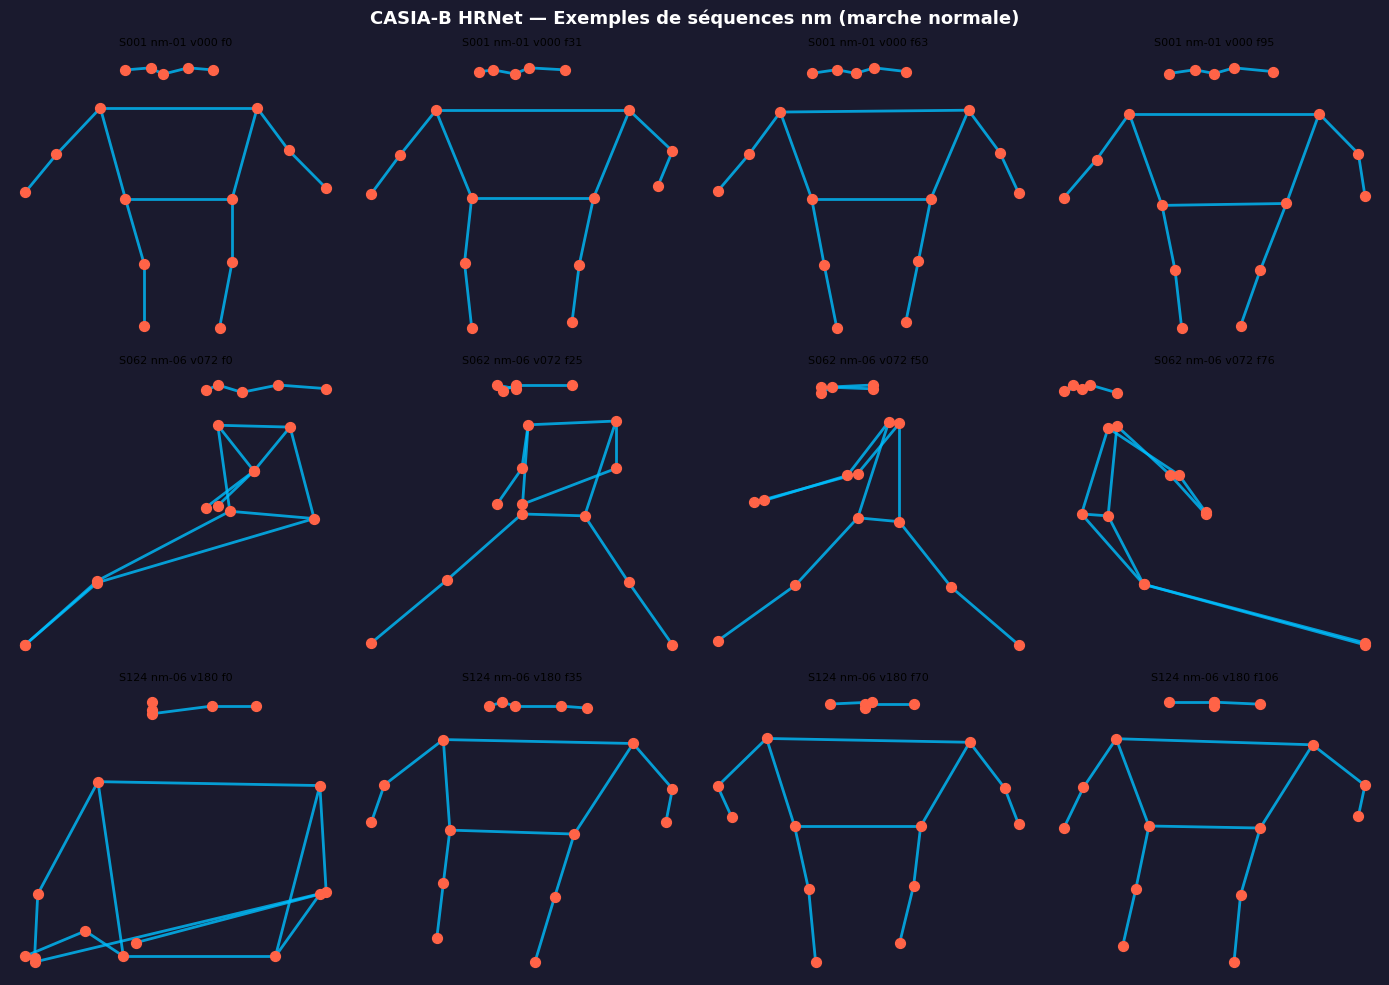


📊 Résumé dataset :
  Séquences totales : 8171
  Frames par séquence : min=25, max=306, moy=98


In [4]:
# ============================================================
# CELL 3 — Visualiser quelques séquences CASIA-B HRNet
# ============================================================
import matplotlib.pyplot as plt

def draw_skeleton(ax, kp, color_bone='royalblue', color_joint='tomato', title=''):
    """
    kp : (17, 2) ou (17, 3) — on prend x,y seulement
    """
    xy = kp[:, :2]
    ax.invert_yaxis()

    for i, j in SKELETON_PAIRS:
        ax.plot([xy[i,0], xy[j,0]],
                [xy[i,1], xy[j,1]],
                color=color_bone, lw=2, alpha=0.8)

    ax.scatter(xy[:,0], xy[:,1], c=color_joint, s=50, zorder=5)
    ax.set_title(title, fontsize=8)
    ax.axis('off')


# Choisir 3 séquences variées
sample_indices = [0, len(sequences)//2, -1]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')

for row, idx in enumerate(sample_indices):
    seq  = sequences[idx]
    meta = metadata[idx]

    # 4 frames réparties sur la séquence
    frame_ids = np.linspace(0, len(seq)-1, 4, dtype=int)

    for col, fi in enumerate(frame_ids):
        ax = axes[row][col]
        ax.set_facecolor('#1a1a2e')
        draw_skeleton(ax, seq[fi],
                      title=f"S{meta['subject']} {meta['condition']}-{meta['sequence']} "
                            f"v{meta['view']} f{fi}",
                      color_bone='deepskyblue',
                      color_joint='tomato')

plt.suptitle("CASIA-B HRNet — Exemples de séquences nm (marche normale)",  # ← mis à jour
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Résumé dataset :")
print(f"  Séquences totales : {len(sequences)}")
print(f"  Frames par séquence : min={min(m['frames'] for m in metadata)}, "
      f"max={max(m['frames'] for m in metadata)}, "
      f"moy={np.mean([m['frames'] for m in metadata]):.0f}")

In [5]:
# ============================================================
# CELL 4 — Feature extraction & sliding windows
#
# POURQUOI cette normalisation ?
# Les coordonnées brutes dépendent de la résolution vidéo.
# Pour que le modèle apprenne des PATTERNS DE MOUVEMENT
# (et non des positions absolues), on normalise :
#   1. Centrage sur la hanche (point stable du corps)
#   2. Mise à l'échelle par la hauteur du torse
# ============================================================

WINDOW_SIZE   = 30   # 30 frames passées → input du LSTM
                     # ~500ms à ~16fps → cohérent avec l'article
PREDICT_STEPS = 8    # 8 frames futures à prédire
                     # ~500ms anticipation (objectif du papier)
STRIDE        = 5    # pas entre fenêtres (évite trop de redondance)
FPS           = 16   # fps estimé CASIA-B

def extract_features(kp_seq):
    """
    Input  : (T, 17, 3)  — coordonnées brutes
    Output : (T, 34)     — features normalisées (x,y relatif × 17)

    Normalisation :
    - Centre = milieu des deux hanches (keypoints 11 et 12)
    - Echelle = distance nez-hanche (hauteur torse approximative)
    """
    xy   = kp_seq[:, :, :2].copy().astype(np.float32)  # (T, 17, 2)

    # Centre = milieu hanches gauche(11) + droite(12)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0   # (T, 2)

    # Coordonnées relatives au centre
    rel = xy - hip_center[:, np.newaxis, :]              # (T, 17, 2)

    # Echelle = distance nez(0) → hanche
    torso_h = np.linalg.norm(xy[:, 0, :] - hip_center, axis=1)  # (T,)
    torso_h = np.maximum(torso_h, 1e-6)                           # évite /0

    # Normalisation
    rel = rel / torso_h[:, np.newaxis, np.newaxis]

    return rel.reshape(len(kp_seq), -1)  # (T, 34)


def build_windows(sequences, window_size=WINDOW_SIZE,
                  predict_steps=PREDICT_STEPS, stride=STRIDE):
    """
    Construit les paires (X, Y) :
    X : fenêtre de WINDOW_SIZE frames passées → input LSTM
    Y : PREDICT_STEPS frames futures          → ce qu'on veut prédire

    Pour chaque séquence de longueur T :
    On glisse une fenêtre et on crée autant d'exemples que possible.
    """
    X_list, Y_list, meta_list = [], [], []

    for i, seq in enumerate(tqdm(sequences, desc="Building windows")):
        feats = extract_features(seq)  # (T, 34)
        T = len(feats)

        min_len = window_size + predict_steps
        if T < min_len:
            continue

        for start in range(0, T - min_len + 1, stride):
            end_x  = start + window_size
            end_y  = end_x  + predict_steps

            X_list.append(feats[start : end_x])   # (30, 34)
            Y_list.append(feats[end_x : end_y])   # ( 8, 34)
            meta_list.append({
                'seq_idx'  : i,
                'start'    : start,
                'subject'  : metadata[i]['subject'],
                'condition': metadata[i]['condition'],
            })

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)

    print(f"\n✅ Fenêtres créées :")
    print(f"   X shape : {X.shape}  →  (N, {window_size} frames, 34 features)")
    print(f"   Y shape : {Y.shape}  →  (N, {predict_steps} frames, 34 features)")
    print(f"   Mémoire : {X.nbytes/1e6:.1f} MB + {Y.nbytes/1e6:.1f} MB")
    print(f"\n   Interprétation :")
    print(f"   → Le LSTM voit {window_size} frames = "
          f"{window_size*1000//FPS}ms de marche passée")
    print(f"   → Il prédit {predict_steps} frames = "
          f"{predict_steps*1000//FPS}ms dans le futur")

    return X, Y, meta_list


X, Y, win_meta = build_windows(sequences)

Building windows: 100%|██████████| 8171/8171 [00:02<00:00, 3519.49it/s]



✅ Fenêtres créées :
   X shape : (102821, 30, 34)  →  (N, 30 frames, 34 features)
   Y shape : (102821, 8, 34)  →  (N, 8 frames, 34 features)
   Mémoire : 419.5 MB + 111.9 MB

   Interprétation :
   → Le LSTM voit 30 frames = 1875ms de marche passée
   → Il prédit 8 frames = 500ms dans le futur


In [6]:
# ============================================================
# CELL 5 — Architecture LSTM Anticipator (+ encode pour Option 1)
# ============================================================

class LSTMAnticipator(nn.Module):
    def __init__(self,
                 input_size    = 34,
                 hidden_size   = 256,
                 num_layers    = 2,
                 predict_steps = PREDICT_STEPS,
                 dropout       = 0.3):
        super().__init__()

        self.predict_steps = predict_steps
        self.input_size    = input_size
        self.hidden_size   = hidden_size

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
        for m in self.fc.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, x):
        """
        Extracteur de features — utilisé pour Option 1.
        x   : (batch, T, 34)
        out : (batch, 256) — représentation dynamique de la marche
        Le LSTM est gelé (frozen) pendant cette étape.
        """
        out, _ = self.lstm(x)            # (batch, T, 256)
        return self.dropout(out[:, -1, :])  # (batch, 256) — dernier état

    def forward(self, x):
        last = self.encode(x)
        pred = self.fc(last)
        return pred.view(x.size(0), self.predict_steps, self.input_size)


# Instanciation
model = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ LSTM Anticipator prêt")
print(f"   Paramètres  : {n_params:,}")
print(f"   Input       : (batch, {WINDOW_SIZE}, 34)")
print(f"   Output pred : (batch, {PREDICT_STEPS}, 34)")
print(f"   Output enc  : (batch, 256)  ← encode() pour Option 1")

dummy = torch.zeros(4, WINDOW_SIZE, 34).to(device)
out   = model(dummy)
enc   = model.encode(dummy)
print(f"   Test forward : {dummy.shape} → {out.shape} ✓")
print(f"   Test encode  : {dummy.shape} → {enc.shape} ✓")

✅ LSTM Anticipator prêt
   Paramètres  : 961,040
   Input       : (batch, 30, 34)
   Output pred : (batch, 8, 34)
   Output enc  : (batch, 256)  ← encode() pour Option 1
   Test forward : torch.Size([4, 30, 34]) → torch.Size([4, 8, 34]) ✓
   Test encode  : torch.Size([4, 30, 34]) → torch.Size([4, 256]) ✓


Train : 82,257 fenêtres | Val : 20,564 fenêtres

🚀 Entraînement sur 80 epochs...

  Epoch 001/80 | Train: 0.02173 | Val: 0.00602 | Best: 0.00602 | LR: 1.00e-03 ⭐
  Epoch 010/80 | Train: 0.00552 | Val: 0.00376 | Best: 0.00376 | LR: 1.00e-03 ⭐
  Epoch 020/80 | Train: 0.00509 | Val: 0.00367 | Best: 0.00364 | LR: 1.00e-03 
  Epoch 030/80 | Train: 0.00489 | Val: 0.00335 | Best: 0.00335 | LR: 5.00e-04 ⭐
  Epoch 040/80 | Train: 0.00485 | Val: 0.00331 | Best: 0.00331 | LR: 5.00e-04 ⭐
  Epoch 050/80 | Train: 0.00476 | Val: 0.00321 | Best: 0.00321 | LR: 2.50e-04 ⭐
  Epoch 060/80 | Train: 0.00477 | Val: 0.00323 | Best: 0.00318 | LR: 2.50e-04 
  Epoch 070/80 | Train: 0.00469 | Val: 0.00317 | Best: 0.00317 | LR: 1.25e-04 ⭐
  Epoch 080/80 | Train: 0.00467 | Val: 0.00315 | Best: 0.00315 | LR: 6.25e-05 


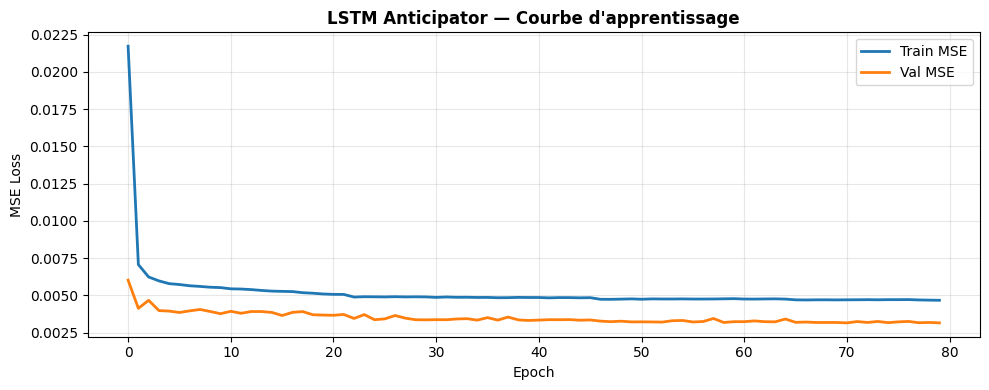


✅ Meilleur Val MSE : 0.003148
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


In [7]:
# ============================================================
# CELL 6 — Training
# ============================================================
from torch.utils.data import Dataset, DataLoader, random_split

class GaitDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]


# --- Split train/val (par fenêtres, pas par sujets — OK pour pré-entraînement) ---
n_total = len(X)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val

dataset  = GaitDataset(X, Y)
tr_set, val_set = random_split(dataset, [n_tr, n_val],
                               generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=256, shuffle=True,
                        num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train : {n_tr:,} fenêtres | Val : {n_val:,} fenêtres")

# --- Optimizer & Scheduler ---
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5)

EPOCHS    = 80
best_val  = float('inf')
tr_hist   = []
val_hist  = []

print(f"\n🚀 Entraînement sur {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    model.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        tr_loss += loss.item()

    # ---- Validate ----
    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl_loss += criterion(model(xb), yb).item()

    tr_loss /= len(tr_loader)
    vl_loss /= len(val_loader)
    tr_hist.append(tr_loss)
    val_hist.append(vl_loss)
    scheduler.step(vl_loss)

    # Sauvegarde meilleur modèle
    is_best = vl_loss < best_val
    if is_best:
        best_val = vl_loss
        torch.save(model.state_dict(), '/content/lstm_anticipator_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:03d}/{EPOCHS} | "
              f"Train: {tr_loss:.5f} | "
              f"Val: {vl_loss:.5f} | "
              f"Best: {best_val:.5f} | "
              f"LR: {current_lr:.2e} "
              f"{'⭐' if is_best else ''}")

# --- Courbe d'apprentissage ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_hist,  label='Train MSE', lw=2)
ax.plot(val_hist, label='Val MSE',   lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Anticipator — Courbe d\'apprentissage', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")

📊 MSE par pas de prédiction :
  t+ 62ms  MSE=0.00103  █████
  t+125ms  MSE=0.00086  ████
  t+187ms  MSE=0.00123  ██████
  t+250ms  MSE=0.00159  ███████
  t+312ms  MSE=0.00127  ██████
  t+375ms  MSE=0.00172  ████████
  t+437ms  MSE=0.00178  ████████
  t+500ms  MSE=0.00191  █████████


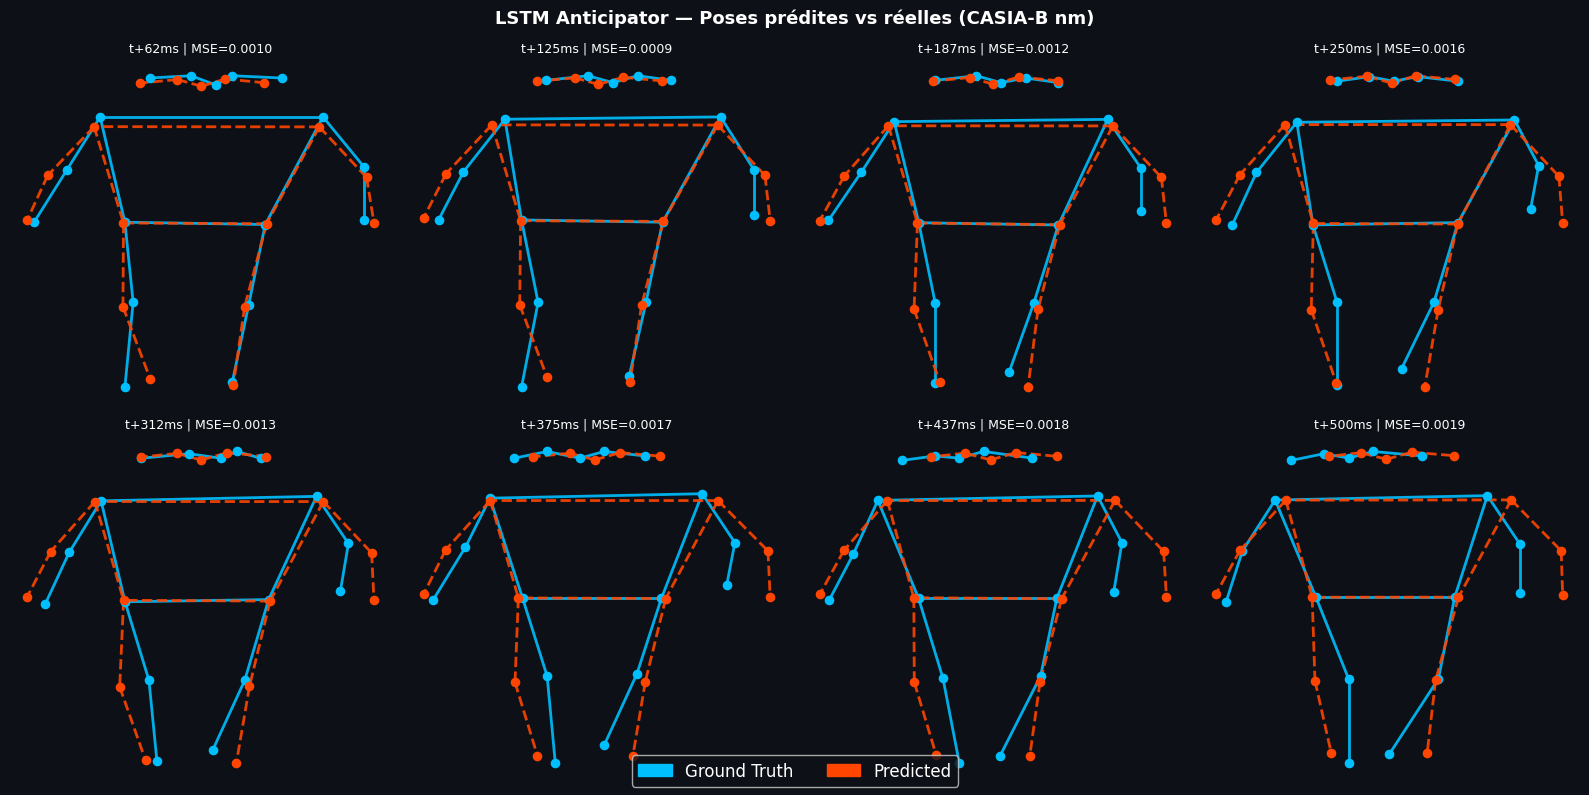

In [8]:
# ============================================================
# CELL 9 — Visualisation poses prédites vs réelles
# ============================================================
import matplotlib.patches as mpatches

model.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth'))
model.eval()

x_samp = dataset[n_tr][0].unsqueeze(0).to(device)
y_true = dataset[n_tr][1].numpy()

with torch.no_grad():
    y_pred = model(x_samp).cpu().numpy()[0]

step_mse = [np.mean((y_pred[s] - y_true[s])**2)
            for s in range(PREDICT_STEPS)]

print("📊 MSE par pas de prédiction :")
for s, mse in enumerate(step_mse):
    ms  = (s + 1) * 1000 // FPS
    bar = '█' * int(mse * 5000)
    print(f"  t+{ms:3d}ms  MSE={mse:.5f}  {bar}")

def flat2kp(arr):
    return arr.reshape(17, 2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')

for step in range(PREDICT_STEPS):
    ax = axes[step // 4][step % 4]
    ax.set_facecolor('#0d1117')
    ax.invert_yaxis()

    gt = flat2kp(y_true[step])
    pr = flat2kp(y_pred[step])

    for i, j in SKELETON_PAIRS:
        ax.plot([gt[i,0], gt[j,0]], [gt[i,1], gt[j,1]],
                color='deepskyblue', lw=2, alpha=0.9)
    ax.scatter(gt[:,0], gt[:,1],
               c='deepskyblue', s=35, zorder=5)

    for i, j in SKELETON_PAIRS:
        ax.plot([pr[i,0], pr[j,0]], [pr[i,1], pr[j,1]],
                color='orangered', lw=2, alpha=0.9,
                linestyle='--')
    ax.scatter(pr[:,0], pr[:,1],
               c='orangered', s=35, zorder=5)

    ms = (step + 1) * 1000 // FPS
    ax.set_title(f"t+{ms}ms | MSE={step_mse[step]:.4f}",
                 color='white', fontsize=9)
    ax.axis('off')

handles = [
    mpatches.Patch(color='deepskyblue', label='Ground Truth'),
    mpatches.Patch(color='orangered',   label='Predicted')
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=12, facecolor='#0d1117',
           labelcolor='white')
fig.suptitle(
    "LSTM Anticipator — Poses prédites vs réelles (CASIA-B nm)",
    color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 10 — Download + Inspect URFD
# ============================================================
import kagglehub, pickle, numpy as np, os
from pathlib import Path
from collections import Counter

urfd_path_raw = kagglehub.dataset_download(
    "mireillejabbour/fall-dataset")
URFD_ROOT = Path(urfd_path_raw)
print(f"✅ URFD path: {URFD_ROOT}\n")

print("=== FOLDER STRUCTURE (4 levels) ===")
for root, dirs, files_ in os.walk(URFD_ROOT):
    level = str(root).replace(
        str(URFD_ROOT), '').count(os.sep)
    if level > 4:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files_)[:5]:
        size = os.path.getsize(
            os.path.join(root, f)) / 1024
        print(f"{indent}  📄 {f}  ({size:.1f} KB)")

all_files = [f for f in URFD_ROOT.rglob('*') if f.is_file()]
exts = Counter(f.suffix.lower() for f in all_files)
print(f"\n=== FILE TYPES ===")
print(f"Total : {len(all_files)}")
for ext, n in exts.most_common():
    print(f"  {ext if ext else 'no_ext'} : {n}")

Using Colab cache for faster access to the 'fall-dataset' dataset.
✅ URFD path: /kaggle/input/fall-dataset

=== FOLDER STRUCTURE (4 levels) ===
fall-dataset/
  fall zip photo files/
    fall zip photo files/
      fall-22-cam1-d/
        fall-22-cam1-d/
          📄 fall-22-cam1-d-001.png  (239.3 KB)
          📄 fall-22-cam1-d-002.png  (235.6 KB)
          📄 fall-22-cam1-d-003.png  (236.9 KB)
          📄 fall-22-cam1-d-004.png  (239.4 KB)
          📄 fall-22-cam1-d-005.png  (240.1 KB)
      fall-26-cam1-rgb/
        fall-26-cam1-rgb/
          📄 fall-26-cam1-rgb-001.png  (402.3 KB)
          📄 fall-26-cam1-rgb-002.png  (401.5 KB)
          📄 fall-26-cam1-rgb-003.png  (401.7 KB)
          📄 fall-26-cam1-rgb-004.png  (401.1 KB)
          📄 fall-26-cam1-rgb-005.png  (399.6 KB)
      fall-09-cam0-d/
        fall-09-cam0-d/
          📄 fall-09-cam0-d-001.png  (268.1 KB)
          📄 fall-09-cam0-d-002.png  (268.6 KB)
          📄 fall-09-cam0-d-003.png  (265.7 KB)
          📄 fall-09-cam0-d-00

In [10]:
# ============================================================
# CELL 11 — Fix NumPy + MediaPipe
# ============================================================
!pip install mediapipe==0.10.14 -q
print("✅ Installation terminée — REDÉMARRE LE KERNEL")
print("   Runtime → Restart session")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
✅ Installation terminée — REDÉMARRE LE KERNEL
   Runtime → Restart session


In [11]:
# ============================================================
# CELL 12 — Extract keypoints URFD (MediaPipe)
# ============================================================
import os, cv2, numpy as np, pickle
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm

print(f"✅ NumPy     version : {np.__version__}")
print(f"✅ MediaPipe version : {mp.__version__}")

URFD_ROOT = Path(urfd_path_raw)
SAVE_PATH = Path("/content/urfd_keypoints")
SAVE_PATH.mkdir(exist_ok=True)

MP_INDICES = [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9,
              12, 11, 14, 13, 16, 15]

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

MODEL_PATH = "/content/pose_landmarker_heavy.task"
if not os.path.exists(MODEL_PATH):
    print("⏳ Téléchargement pose_landmarker_heavy.task...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/"
        "pose_landmarker/pose_landmarker_heavy/float16/"
        "latest/pose_landmarker_heavy.task",
        MODEL_PATH
    )
    print("✅ Modèle téléchargé")
else:
    print("✅ Modèle déjà présent")

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    num_poses=1,
    min_pose_detection_confidence=0.1,
    min_pose_presence_confidence=0.1,
    min_tracking_confidence=0.1,
    running_mode=vision.RunningMode.IMAGE
)
pose = vision.PoseLandmarker.create_from_options(options)
print("✅ PoseLandmarker initialisé\n")


def extract_keypoints_mediapipe(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results  = pose.detect(mp_image)
    if (not results.pose_landmarks
            or len(results.pose_landmarks) == 0):
        return None
    lm = results.pose_landmarks[0]
    kp = np.zeros((17, 3), dtype=np.float32)
    for coco_idx, mp_idx in enumerate(MP_INDICES):
        kp[coco_idx, 0] = lm[mp_idx].x * w
        kp[coco_idx, 1] = lm[mp_idx].y * h
        kp[coco_idx, 2] = getattr(
            lm[mp_idx], 'visibility', 1.0)
    return kp


def process_sequence(seq_dir, min_frames=5, min_rate=0.5):
    frames = sorted(seq_dir.glob("*.png"))
    if len(frames) == 0:
        return None
    keypoints = []
    for fp in frames:
        kp = extract_keypoints_mediapipe(fp)
        if kp is not None:
            keypoints.append(kp)
    detection_rate = len(keypoints) / max(len(frames), 1)
    if (len(keypoints) < min_frames
            or detection_rate < min_rate):
        return None
    return np.stack(keypoints, axis=0)


def get_actual_dir(seq_dir):
    inner = [d for d in seq_dir.iterdir() if d.is_dir()]
    return inner[0] if len(inner) == 1 else seq_dir


print("=" * 55)
print("📂 Processing FALL sequences — TOUTES VUES")
print("=" * 55)
fall_root = (URFD_ROOT / "fall zip photo files"
             / "fall zip photo files")

fall_dirs      = sorted([d for d in fall_root.iterdir()
                         if d.is_dir()])
fall_sequences = {}
skipped_falls  = []

for seq_dir in tqdm(fall_dirs, desc="Falls"):
    actual_dir = get_actual_dir(seq_dir)
    kp_seq     = process_sequence(actual_dir)
    if kp_seq is not None:
        fall_sequences[seq_dir.name] = kp_seq
    else:
        skipped_falls.append(seq_dir.name)

print(f"\n  ✅ Falls : {len(fall_sequences)}/{len(fall_dirs)}")

print("\n" + "=" * 55)
print("📂 Processing ADL sequences — TOUTES VUES")
print("=" * 55)
adl_root = (URFD_ROOT / "adl zip photo files"
            / "adl zip photo files")

adl_dirs      = sorted([d for d in adl_root.iterdir()
                        if d.is_dir()])
adl_sequences = {}
skipped_adls  = []

for seq_dir in tqdm(adl_dirs, desc="ADLs"):
    actual_dir = get_actual_dir(seq_dir)
    kp_seq     = process_sequence(actual_dir)
    if kp_seq is not None:
        adl_sequences[seq_dir.name] = kp_seq
    else:
        skipped_adls.append(seq_dir.name)

print(f"\n  ✅ ADLs : {len(adl_sequences)}/{len(adl_dirs)}")

print("\n💾 Sauvegarde...")
with open(SAVE_PATH / "fall_keypoints.pkl", 'wb') as f:
    pickle.dump(fall_sequences, f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'wb') as f:
    pickle.dump(adl_sequences, f)

all_fall_len = [v.shape[0] for v in fall_sequences.values()]
all_adl_len  = [v.shape[0] for v in adl_sequences.values()]

print(f"\n{'='*55}")
print(f"✅ URFD Keypoints Extraction — COMPLETE")
print(f"  Fall sequences : {len(fall_sequences)}")
print(f"  ADL  sequences : {len(adl_sequences)}")
print(f"  Fall frames    : "
      f"min={min(all_fall_len)} | "
      f"max={max(all_fall_len)} | "
      f"total={sum(all_fall_len)}")
print(f"  ADL  frames    : "
      f"min={min(all_adl_len)} | "
      f"max={max(all_adl_len)} | "
      f"total={sum(all_adl_len)}")
print(f"{'='*55}")

✅ NumPy     version : 2.0.2
✅ MediaPipe version : 0.10.14
⏳ Téléchargement pose_landmarker_heavy.task...
✅ Modèle téléchargé
✅ PoseLandmarker initialisé

📂 Processing FALL sequences — TOUTES VUES


Falls:   0%|          | 0/118 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Falls: 100%|██████████| 118/118 [32:53<00:00, 16.73s/it]



  ✅ Falls : 110/118

📂 Processing ADL sequences — TOUTES VUES


ADLs: 100%|██████████| 80/80 [44:03<00:00, 33.05s/it]


  ✅ ADLs : 66/80

💾 Sauvegarde...

✅ URFD Keypoints Extraction — COMPLETE
  Fall sequences : 110
  ADL  sequences : 66
  Fall frames    : min=40 | max=212 | total=9844
  ADL  frames    : min=51 | max=309 | total=10854


In [13]:
# ============================================================
# CELL 13 — Labellisation URFD
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH = Path("/content/urfd_keypoints")

with open(SAVE_PATH / "fall_keypoints.pkl", 'rb') as f:
    fall_sequences = pickle.load(f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'rb') as f:
    adl_sequences = pickle.load(f)

FPS        = 30
PRE_FALL_F = 20
FALL_F     = 15

print(f"Fall sequences : {len(fall_sequences)}")
print(f"ADL  sequences : {len(adl_sequences)}")

def label_fall_sequence(T):
    labels        = np.zeros(T, dtype=np.int64)
    fall_start    = max(0, T - FALL_F)
    prefall_start = max(0, T - FALL_F - PRE_FALL_F)
    labels[prefall_start:fall_start] = 1
    labels[fall_start:]              = 2
    return labels

labeled_data = []

for name, kp in fall_sequences.items():
    T      = kp.shape[0]
    labels = label_fall_sequence(T)
    labeled_data.append({
        'keypoints': kp,
        'labels':    labels,
        'name':      name,
        'is_fall':   True
    })

for name, kp in adl_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    np.zeros(T, dtype=np.int64),
        'name':      name,
        'is_fall':   False
    })

all_labels = np.concatenate(
    [d['labels'] for d in labeled_data])
counts = Counter(all_labels.tolist())
total  = len(all_labels)

print(f"\n📊 Label distribution :")
print(f"  0 STABLE   : {counts[0]:6d} ({100*counts[0]/total:.1f}%)")
print(f"  1 PRE-FALL : {counts[1]:6d} ({100*counts[1]/total:.1f}%)")
print(f"  2 FALL     : {counts[2]:6d} ({100*counts[2]/total:.1f}%)")

with open(SAVE_PATH / "labeled_data.pkl", 'wb') as f:
    pickle.dump(labeled_data, f)
print(f"\n✅ Saved: labeled_data.pkl")

Fall sequences : 110
ADL  sequences : 66

📊 Label distribution :
  0 STABLE   :  16848 (81.4%)
  1 PRE-FALL :   2200 (10.6%)
  2 FALL     :   1650 (8.0%)

✅ Saved: labeled_data.pkl


In [14]:
# ============================================================
# CELL 14 — Preprocessing URFD → X_urfd.npy
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH   = Path("/content/urfd_keypoints")
WINDOW_SIZE = 30
STRIDE      = 1

with open(SAVE_PATH / "labeled_data.pkl", 'rb') as f:
    labeled_data = pickle.load(f)

def extract_features_urfd(kp_seq):
    xy         = kp_seq[:, :, :2].copy()
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

X_all = {0: [], 1: [], 2: []}

for sample in labeled_data:
    kp   = sample['keypoints']
    labs = sample['labels']
    T    = len(kp)
    if T < WINDOW_SIZE + 1:
        continue
    feats = extract_features_urfd(kp)

    for start in range(0, T - WINDOW_SIZE):
        end       = start + WINDOW_SIZE
        win_label = int(labs[end - 1])
        X_all[win_label].append(feats[start:end])

print("📊 Avant équilibrage :")
for cls, name in [(0,'STABLE'),(1,'PRE-FALL'),(2,'FALL')]:
    print(f"  {name:12} : {len(X_all[cls]):6d} fenêtres")

n_min = min(len(X_all[0]), len(X_all[1]), len(X_all[2]))
print(f"\n  Classe minoritaire : {n_min} fenêtres")

np.random.seed(42)
X_balanced = []
Y_balanced = []

for cls in [0, 1, 2]:
    arr = np.array(X_all[cls])
    if len(arr) > n_min:
        idx = np.random.choice(len(arr), n_min, replace=False)
        arr = arr[idx]
    X_balanced.append(arr)
    Y_balanced.append(np.full(len(arr), cls, dtype=np.int64))

X = np.concatenate(X_balanced, axis=0)
Y = np.concatenate(Y_balanced, axis=0)

shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
Y = Y[shuffle_idx]

counts = Counter(Y.tolist())
total  = len(Y)
print(f"\n📊 Après équilibrage :")
print(f"  X shape      : {X.shape}")
print(f"  STABLE   (0) : {counts[0]} ({100*counts[0]/total:.1f}%)")
print(f"  PRE-FALL (1) : {counts[1]} ({100*counts[1]/total:.1f}%)")
print(f"  FALL     (2) : {counts[2]} ({100*counts[2]/total:.1f}%)")
print(f"  Ratio        : 1:1:1 ✅")

np.save(SAVE_PATH / "X_urfd.npy", X.astype(np.float32))
np.save(SAVE_PATH / "Y_urfd.npy", Y)
print(f"\n✅ Saved: X_urfd.npy, Y_urfd.npy")

📊 Avant équilibrage :
  STABLE       :  11994 fenêtres
  PRE-FALL     :   1888 fenêtres
  FALL         :   1536 fenêtres

  Classe minoritaire : 1536 fenêtres

📊 Après équilibrage :
  X shape      : (4608, 30, 34)
  STABLE   (0) : 1536 (33.3%)
  PRE-FALL (1) : 1536 (33.3%)
  FALL     (2) : 1536 (33.3%)
  Ratio        : 1:1:1 ✅

✅ Saved: X_urfd.npy, Y_urfd.npy


In [15]:
# ============================================================
# CELL 15 — Feature Extraction LSTM sur URFD
# ============================================================
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

SAVE_PATH = Path("/content/urfd_keypoints")
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

# Charger LSTM pré-entraîné
lstm_model = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(DEVICE)

lstm_model.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE)
)

# Geler tous les poids
for param in lstm_model.parameters():
    param.requires_grad = False
lstm_model.eval()

n_frozen = sum(p.numel() for p in lstm_model.parameters())
print(f"✅ LSTM chargé et gelé")
print(f"   Paramètres gelés : {n_frozen:,}")
print(f"   → LSTM ne sera PAS modifié pendant training DGNN")

# Charger URFD
X_urfd = np.load(SAVE_PATH / "X_urfd.npy")
Y_urfd = np.load(SAVE_PATH / "Y_urfd.npy")
print(f"\n📊 URFD : X={X_urfd.shape} | Y={Y_urfd.shape}")

# Extraction par batch
BATCH_SIZE    = 256
X_tensor      = torch.tensor(X_urfd, dtype=torch.float32)
lstm_features = []

print(f"\n⏳ Extraction features LSTM...")

with torch.no_grad():
    for i in tqdm(range(0, len(X_tensor), BATCH_SIZE),
                  desc="LSTM encode"):
        batch = X_tensor[i:i+BATCH_SIZE].to(DEVICE)
        feat  = lstm_model.encode(batch)
        lstm_features.append(feat.cpu().numpy())

lstm_features = np.concatenate(lstm_features, axis=0)

print(f"\n✅ Features extraites :")
print(f"   Shape   : {lstm_features.shape}  → (N, 256)")
print(f"   Mémoire : {lstm_features.nbytes/1e6:.1f} MB")

np.save(SAVE_PATH / "lstm_features_urfd.npy",
        lstm_features.astype(np.float32))
print(f"\n💾 Sauvegardé : lstm_features_urfd.npy")
print(f"\n   STABLE   → features proches CASIA-B")
print(f"   PRE-FALL → features qui s'écartent")
print(f"   FALL     → features très différentes ✅")

✅ LSTM chargé et gelé
   Paramètres gelés : 961,040
   → LSTM ne sera PAS modifié pendant training DGNN

📊 URFD : X=(4608, 30, 34) | Y=(4608,)

⏳ Extraction features LSTM...


LSTM encode: 100%|██████████| 18/18 [00:00<00:00, 122.78it/s]


✅ Features extraites :
   Shape   : (4608, 256)  → (N, 256)
   Mémoire : 4.7 MB

💾 Sauvegardé : lstm_features_urfd.npy

   STABLE   → features proches CASIA-B
   PRE-FALL → features qui s'écartent
   FALL     → features très différentes ✅


In [16]:
# ============================================================
# CELL 16 — Architecture DGNN + Gate Fusion
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_JOINTS = 17

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def build_adjacency():
    A_src  = torch.zeros(N_JOINTS, N_JOINTS)
    A_tgt  = torch.zeros(N_JOINTS, N_JOINTS)
    A_self = torch.eye(N_JOINTS)
    for (i, j) in COCO_EDGES:
        A_src[i, j] = 1.0
        A_tgt[j, i] = 1.0
    def normalize(A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        return A / D
    return normalize(A_src), normalize(A_tgt), A_self


class DGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W_src  = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.W_tgt  = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.W_self = nn.Linear(in_channels, out_channels,
                                bias=False)
        self.bn  = nn.BatchNorm1d(out_channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x, A_src, A_tgt, A_self):
        B, N, C = x.shape
        h_src  = torch.bmm(
            A_src.unsqueeze(0).expand(B,-1,-1), x)
        h_tgt  = torch.bmm(
            A_tgt.unsqueeze(0).expand(B,-1,-1), x)
        h_self = torch.bmm(
            A_self.unsqueeze(0).expand(B,-1,-1), x)
        out = (self.W_src(h_src) + self.W_tgt(h_tgt)
               + self.W_self(h_self))
        out = self.bn(out.view(B*N, -1)).view(B, N, -1)
        return self.act(out)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    def forward(self, x):
        scores  = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = (weights * x).sum(dim=1)
        return context, weights


class GateFusion(nn.Module):
    """
    gate   = sigmoid(W * [dgnn_feat ; lstm_proj])
    output = gate * dgnn_feat + (1-gate) * lstm_proj

    gate ≈ 1 → DGNN domine  (mouvement anormal)
    gate ≈ 0 → LSTM domine  (marche normale reconnue)
    """
    def __init__(self, dgnn_dim=512, lstm_dim=256):
        super().__init__()
        self.lstm_proj = nn.Linear(lstm_dim, dgnn_dim)
        self.gate = nn.Sequential(
            nn.Linear(dgnn_dim * 2, dgnn_dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dgnn_dim)

    def forward(self, dgnn_feat, lstm_feat):
        lstm_proj = self.lstm_proj(lstm_feat)
        combined  = torch.cat([dgnn_feat, lstm_proj], dim=1)
        g         = self.gate(combined)
        fused     = g * dgnn_feat + (1 - g) * lstm_proj
        return self.norm(fused)


class DGNNWithLSTMFeatures(nn.Module):
    """
    Input :
      x         : (batch, 30, 34) — keypoints URFD
      lstm_feat : (batch, 256)    — features LSTM gelées

    Output :
      logits    : (batch, 3)      — STABLE/PRE-FALL/FALL
    """
    def __init__(self, T=30, n_classes=3, hidden=64,
                 lstm_feat_dim=256):
        super().__init__()

        self.T          = T
        self.input_proj = nn.Linear(2, hidden)
        self.dgnn1      = DGNNLayer(hidden,   hidden)
        self.dgnn2      = DGNNLayer(hidden,   hidden * 2)
        self.dgnn3      = DGNNLayer(hidden*2, hidden * 2)
        gru_input       = N_JOINTS * hidden * 2
        self.gru        = nn.GRU(
            input_size    = gru_input,
            hidden_size   = 256,
            num_layers    = 2,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )
        self.temporal_attn = TemporalAttention(512)
        self.gate_fusion   = GateFusion(
            dgnn_dim = 512,
            lstm_dim = lstm_feat_dim
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

        A_src, A_tgt, A_self = build_adjacency()
        self.register_buffer('A_src',  A_src)
        self.register_buffer('A_tgt',  A_tgt)
        self.register_buffer('A_self', A_self)

    def forward(self, x, lstm_feat):
        B, T, _ = x.shape
        xg = x.view(B, T, N_JOINTS, 2)

        frame_features = []
        for t in range(T):
            xt = xg[:, t, :, :]
            xt = self.input_proj(xt)
            xt = self.dgnn1(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = self.dgnn2(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = self.dgnn3(xt, self.A_src,
                            self.A_tgt, self.A_self)
            xt = xt.view(B, -1)
            frame_features.append(xt)

        seq          = torch.stack(frame_features, dim=1)
        gru_out, _   = self.gru(seq)
        dgnn_feat, _ = self.temporal_attn(gru_out)

        fused = self.gate_fusion(dgnn_feat, lstm_feat)
        return self.classifier(fused)


# Instanciation
model_dgnn_lstm = DGNNWithLSTMFeatures(
    T             = 30,
    n_classes     = 3,
    hidden        = 64,
    lstm_feat_dim = 256
).to(DEVICE)

n_train = sum(p.numel() for p in model_dgnn_lstm.parameters()
              if p.requires_grad)
print(f"✅ DGNNWithLSTMFeatures instancié")
print(f"   Paramètres à entraîner : {n_train:,}")
print(f"   Input X                : (batch, 30, 34)")
print(f"   Input lstm_feat        : (batch, 256) gelé")
print(f"   Output                 : (batch, 3)")

dummy_x    = torch.zeros(4, 30, 34).to(DEVICE)
dummy_lstm = torch.zeros(4, 256).to(DEVICE)
out        = model_dgnn_lstm(dummy_x, dummy_lstm)
print(f"   Test forward           : → {out.shape} ✓")

✅ DGNNWithLSTMFeatures instancié
   Paramètres à entraîner : 5,961,796
   Input X                : (batch, 30, 34)
   Input lstm_feat        : (batch, 256) gelé
   Output                 : (batch, 3)
   Test forward           : → torch.Size([4, 3]) ✓


In [ ]:
# ============================================================
# CELL 17 — Entraînement DGNN+LSTM (Feature Extraction)
# Sans comparaison — résultats directs
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_PATH = Path("/content/urfd_keypoints")
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED      = 42

# ── Charger données ───────────────────────────────────────────
X_urfd        = np.load(SAVE_PATH / "X_urfd.npy")
Y_urfd        = np.load(SAVE_PATH / "Y_urfd.npy")
lstm_features = np.load(SAVE_PATH / "lstm_features_urfd.npy")

print(f"X_urfd        : {X_urfd.shape}")
print(f"Y_urfd        : {Y_urfd.shape}")
print(f"lstm_features : {lstm_features.shape}")

# ── Dataset ───────────────────────────────────────────────────
class URFDWithLSTMDataset(Dataset):
    def __init__(self, X, L, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.L = torch.tensor(L, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.L[i], self.Y[i]


dataset = URFDWithLSTMDataset(X_urfd, lstm_features, Y_urfd)
n_total = len(dataset)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val

tr_set, val_set = random_split(
    dataset, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
tr_loader  = DataLoader(tr_set,  batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

counts = {0: 0, 1: 0, 2: 0}
for _, _, yb in tr_loader:
    for y in yb.numpy():
        counts[int(y)] += 1

print(f"\nTrain : {n_tr:,} | Val : {n_val:,}")
print(f"  STABLE   : {counts[0]} ({100*counts[0]/n_tr:.1f}%)")
print(f"  PRE-FALL : {counts[1]} ({100*counts[1]/n_tr:.1f}%)")
print(f"  FALL     : {counts[2]} ({100*counts[2]/n_tr:.1f}%)")

# ── Focal Loss ────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce  = F.cross_entropy(inputs, targets,
                              reduction='none')
        pt  = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(
    model_dgnn_lstm.parameters(),
    lr=5e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=200, eta_min=1e-6
)

# ── Fonctions ─────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit):
    model.train()
    total = 0.0
    for xb, lb, yb in loader:
        xb, lb, yb = (xb.to(DEVICE), lb.to(DEVICE),
                      yb.to(DEVICE))
        opt.zero_grad()
        loss = crit(model(xb, lb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += loss.item()
    return total / len(loader)

def eval_epoch(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, lb, yb in loader:
            xb, lb = xb.to(DEVICE), lb.to(DEVICE)
            p = model(xb, lb).argmax(dim=1).cpu().numpy()
            preds.extend(p)
            labels.extend(yb.numpy())
    preds  = np.array(preds)
    labels = np.array(labels)
    acc    = np.mean(preds == labels)
    f1     = f1_score(labels, preds, average='macro')
    f1_all = f1_score(labels, preds, average=None,
                      zero_division=0)
    return acc, f1, f1_all, labels, preds

# ── Entraînement ──────────────────────────────────────────────
EPOCHS  = 200
best_f1 = 0.0
hist    = []

print(f"\n🚀 Entraînement DGNN+LSTM — {EPOCHS} epochs")
print(f"   Stratégie : Feature Extraction (LSTM gelé)")
print(f"   Fusion    : Gate Mechanism")
print(f"   Focal Loss: gamma=2.0")
print(f"   Scheduler : CosineAnnealingLR (5e-4 → 1e-6)\n")

for epoch in range(1, EPOCHS + 1):
    loss                    = train_epoch(
        model_dgnn_lstm, tr_loader, optimizer, criterion)
    acc, f1, f1_all, _, _   = eval_epoch(
        model_dgnn_lstm, val_loader)
    scheduler.step()

    f1_pre  = f1_all[1] if len(f1_all) > 1 else 0.0
    f1_fall = f1_all[2] if len(f1_all) > 2 else 0.0

    hist.append({
        'epoch':   epoch,
        'loss':    loss,
        'acc':     acc,
        'f1':      f1,
        'f1_pre':  f1_pre,
        'f1_fall': f1_fall
    })

    is_best = f1 > best_f1
    if is_best:
        best_f1 = f1
        torch.save({
            'epoch':       epoch,
            'val_f1':      f1,
            'val_acc':     acc,
            'model_state': model_dgnn_lstm.state_dict()
        }, '/content/dgnn_lstm_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:03d} | "
              f"Loss: {loss:.4f} | "
              f"Acc: {acc:.3f} | "
              f"F1macro: {f1:.3f} | "
              f"F1_pre: {f1_pre:.3f} | "
              f"F1_fall: {f1_fall:.3f} | "
              f"LR: {lr:.1e} "
              f"{'⭐' if is_best else ''}")

# ── Rapport final ─────────────────────────────────────────────
print("\n" + "="*55)
ckpt = torch.load('/content/dgnn_lstm_best.pth',
                  map_location=DEVICE)
model_dgnn_lstm.load_state_dict(ckpt['model_state'])
print(f"✅ Best model : epoch {ckpt['epoch']} | "
      f"F1={ckpt['val_f1']:.4f}")

# Threshold sweep
model_dgnn_lstm.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for xb, lb, yb in val_loader:
        xb, lb = xb.to(DEVICE), lb.to(DEVICE)
        all_logits.append(
            model_dgnn_lstm(xb, lb).cpu())
        all_true.extend(yb.tolist())

all_logits = torch.cat(all_logits)
all_probs  = torch.softmax(all_logits, dim=1).numpy()
all_true   = np.array(all_true)

print("\n  Threshold sweep :")
best_thresh, best_fall_f1 = 0.3, 0.0
for thresh in np.arange(0.10, 0.60, 0.05):
    preds_t = all_logits.argmax(dim=1).numpy().copy()
    preds_t[all_probs[:, 2] > thresh] = 2
    f1_t    = f1_score(all_true, preds_t,
                       average=None, zero_division=0)
    f1_mac  = f1_score(all_true, preds_t,
                       average='macro', zero_division=0)
    f1_fall = f1_t[2] if len(f1_t) > 2 else 0
    print(f"    thresh={thresh:.2f} | "
          f"F1_fall={f1_fall:.3f} | "
          f"F1_macro={f1_mac:.3f}")
    if f1_fall > best_fall_f1:
        best_fall_f1  = f1_fall
        best_thresh   = thresh

print(f"\n✅ Best threshold : {best_thresh:.2f} → "
      f"F1_fall={best_fall_f1:.3f}")

# Rapport classification
preds_final = all_logits.argmax(dim=1).numpy().copy()
preds_final[all_probs[:, 2] > best_thresh] = 2

print("\n📊 RAPPORT FINAL :")
print("="*55)
print(classification_report(
    all_true, preds_final,
    target_names=['STABLE', 'PRE-FALL', 'FALL']))

# Progression historique
f1c = f1_score(all_true, preds_final,
               average=None, zero_division=0)
mac = f1_score(all_true, preds_final,
               average='macro', zero_division=0)

print("📊 PROGRESSION HISTORIQUE :")
print(f"  {'':12} {'V1':>7} {'V2':>7} {'V3':>7} "
      f"{'V4':>7} {'DGNN':>7} {'DGNN+LSTM':>10}")
print(f"  {'STABLE':12} {'0.91':>7} {'0.94':>7} "
      f"{'0.96':>7} {'0.99':>7} {'0.98':>7} "
      f"{f1c[0]:.2f}{'>':>8}")
print(f"  {'PRE-FALL':12} {'0.25':>7} {'0.71':>7} "
      f"{'0.75':>7} {'0.76':>7} {'0.95':>7} "
      f"{f1c[1]:.2f}{'>':>8}")
print(f"  {'FALL':12} {'0.00':>7} {'0.86':>7} "
      f"{'0.84':>7} {'0.86':>7} {'0.97':>7} "
      f"{f1c[2]:.2f}{'>':>8}")
print(f"  {'F1 macro':12} {'0.56':>7} {'0.84':>7} "
      f"{'0.85':>7} {'0.87':>7} {'0.97':>7} "
      f"{mac:.2f}{'>':>8}")
print(f"  {'Accuracy':12} {'0.79':>7} {'0.88':>7} "
      f"{'0.90':>7} {'0.95':>7} {'0.97':>7} "
      f"{ckpt['val_acc']:.2f}{'>':>8}")

# ── Courbes ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_ = [h['epoch']   for h in hist]
loss_   = [h['loss']    for h in hist]
f1mac_  = [h['f1']      for h in hist]
f1pre_  = [h['f1_pre']  for h in hist]
f1fall_ = [h['f1_fall'] for h in hist]

axes[0].plot(epochs_, loss_, color='tomato')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_, f1mac_,  color='steelblue',
             label='F1 macro')
axes[1].plot(epochs_, f1pre_,  color='orange',
             label='F1 PRE-FALL')
axes[1].plot(epochs_, f1fall_, color='tomato',
             label='F1 FALL')
axes[1].axhline(y=0.97, color='green', ls='--',
                alpha=0.7, label='DGNN seul (0.97)')
axes[1].legend()
axes[1].set_title('F1 Scores — DGNN+LSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

from collections import Counter
counts_val = Counter(all_true.tolist())
axes[2].bar(
    ['STABLE', 'PRE-FALL', 'FALL'],
    [counts_val[0], counts_val[1], counts_val[2]],
    color=['steelblue', 'orange', 'tomato']
)
axes[2].set_title('Distribution val set\n(équilibré 1:1:1)')

plt.suptitle(
    f'DGNN + LSTM (Feature Extraction | Gate Fusion)\n'
    f'Best epoch={ckpt["epoch"]} | '
    f'F1={ckpt["val_f1"]:.4f} | '
    f'Acc={ckpt["val_acc"]:.4f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/content/dgnn_lstm_training.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\n🎯 Résumé final :")
print(f"   Best epoch  : {ckpt['epoch']}")
print(f"   F1 macro    : {ckpt['val_f1']:.4f}")
print(f"   Accuracy    : {ckpt['val_acc']:.4f}")
print(f"   Modèle      : /content/dgnn_lstm_best.pth")
print(f"   Courbes     : /content/dgnn_lstm_training.png")

from google.colab import files
files.download('/content/dgnn_lstm_training.png')


X_urfd        : (4608, 30, 34)
Y_urfd        : (4608,)
lstm_features : (4608, 256)

Train : 3,687 | Val : 921
  STABLE   : 1230 (33.4%)
  PRE-FALL : 1242 (33.7%)
  FALL     : 1215 (33.0%)

🚀 Entraînement DGNN+LSTM — 200 epochs
   Stratégie : Feature Extraction (LSTM gelé)
   Fusion    : Gate Mechanism
   Focal Loss: gamma=2.0
   Scheduler : CosineAnnealingLR (5e-4 → 1e-6)

Ep 001 | Loss: 0.0183 | Acc: 0.953 | F1macro: 0.953 | F1_pre: 0.929 | F1_fall: 0.952 | LR: 5.0e-04 ⭐
Ep 010 | Loss: 0.0162 | Acc: 0.887 | F1macro: 0.887 | F1_pre: 0.873 | F1_fall: 0.904 | LR: 5.0e-04 
Ep 020 | Loss: 0.0033 | Acc: 0.953 | F1macro: 0.953 | F1_pre: 0.931 | F1_fall: 0.955 | LR: 4.9e-04 
